# Latent-compression surrogates — SVD and Tucker

Section *Latent compression* (single-mode SVD and joint-mode Tucker) and the per-checkpoint
histograms of Appendix A.

Both variants compress the surrogate **target** offline, in the Laplace latent space, and
back-project before decoding. They differ only in how many modes of the latent tensor
$\hat{\mathcal{Z}} \in \mathbb{C}^{n_s \times K \times d_z}$ they factorise:

| | frequency mode $K$ | latent mode $d_z$ | target size |
|---|---|---|---|
| direct  | — | — | $K d_z = 1024$ |
| **SVD**    | *not compressed* | $\to k_{\mathrm{svd}}$ | $K\,k_{\mathrm{svd}}$ |
| **Tucker** | $\to r_s$ | $\to r_z$ | $r_s r_z$ |

SVD is therefore **Tucker at $r_s = K$**: the frequency factor $U^{(s)}$ becomes a square
unitary matrix, $U^{(s)}U^{(s)H} = I$, and only the latent factor survives, with
$V \equiv U^{(z)}$ and $k_{\mathrm{svd}} \equiv r_z$. The two families are handled by a single
code path here — SVD models simply expose $U^{(s)} = I_K$ — and the SVD checkpoints occupy the
$r_s = K$ row of one common rank grid. Section 4 checks that identity numerically.

In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import gc
import glob
import re
import functools

import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline
from laplace_surrogate.models.encoder_decoder import ConvEncoder
from laplace_surrogate.models import tucker

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device, torch.cuda.get_device_name(0) if device == 'cuda' else '')

Device: cuda NVIDIA RTX A5000


/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Article figure style; `run` prefixes the output filenames.
import figstyle
figstyle.setup(run='compress')     # titles=True pour garder les suptitle en interactif

figstyle: style=paper.mplstyle  run=compress  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Dataset loading

In [3]:
DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '/users/eleves-b/2023/keyvan.attarian/diffusion_ae/checkpoints'
CACHE_DIR  = 'cache_compress'
N          = 128
BATCH_SIZE = 16

R_S_GRID   = (4, 8)       # Tucker frequency-mode ranks under study; the r_s = K row of the
                          # grid is filled by the SVD checkpoints (Section 4).

os.makedirs(CACHE_DIR, exist_ok=True)

U_raw = np.load(DATA_PATH, mmap_mode='r')
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} simulations, Nt={Nt_full}, {H}x{W}')

doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)

split    = np.load(SPLIT_PATH)
test_idx = split['test_idx'].tolist()
print(f'Test set: {len(test_idx)} simulations')

Dataset: 8100 simulations, Nt=150, 128x128
Test set: 1620 simulations


In [4]:
def load_u(idx: int) -> np.ndarray:
    """Load U and resize to (Nt, N, N) float32."""
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u


def load_u_batch(idx_list) -> np.ndarray:
    return np.stack([load_u(i) for i in idx_list])

## 2. Checkpoints

All checkpoints share the same phase-1 autoencoder ($d_z = 64$, $K = 16$, $\gamma = 0.01$) —
only the offline factors and the surrogate differ, so the whole sweep is a comparison at fixed AE.

Every checkpoint is described by the same pair of ranks $(r_s, r_z)$: for Tucker they are the two
HOOI ranks, for SVD they are $(K, k_{\mathrm{svd}})$, the frequency mode being left intact. Epoch
and best `val/l2rel` are read from the `ModelCheckpoint` callback state.

In [5]:
_TUCK_PAT = re.compile(
    r'^(?P<cls>\w+?)__(?P<ae_stem>.+?)__t(?P<n_trunk>\d+)h(?P<n_head>\d+)'
    r'_rs(?P<r_s>\d+)rz(?P<r_z>\d+)$'
)
_SVD_PAT = re.compile(
    r'^(?P<cls>\w+?)__(?P<ae_stem>.+?)__t(?P<n_trunk>\d+)h(?P<n_head>\d+)'
    r'_ksvd(?P<k_svd>\d+)$'
)

PALETTE = dict(figstyle.MODEL_COLORS)   # palette partagee — voir notebooks/figstyle.py
FAMILY  = {'SLAETuckerModel': 'SLAE-Tucker', 'LLAETuckerModel': 'LLAE-Tucker',
           'SLAESVDModel':    'SLAE-SVD',    'LLAESVDModel':    'LLAE-SVD'}
FAM     = {'SLAETuckerModel': 'SLAE', 'SLAESVDModel': 'SLAE',
           'LLAETuckerModel': 'LLAE', 'LLAESVDModel': 'LLAE'}
METHOD  = {'SLAETuckerModel': 'Tucker', 'LLAETuckerModel': 'Tucker',
           'SLAESVDModel':    'SVD',    'LLAESVDModel':    'SVD'}


def _best_val_l2rel(ckpt: dict):
    """Best val/l2rel, stored in the ModelCheckpoint callback state."""
    for v in ckpt.get('callbacks', {}).values():
        if isinstance(v, dict) and v.get('best_model_score') is not None:
            return float(v['best_model_score'])
    return float('nan')


def _describe(path, cls, r_s, r_z):
    ck    = torch.load(path, map_location='cpu', weights_only=False)
    state = ck['model_state']
    d = dict(
        path   = path,
        cls    = cls,
        family = FAM[cls],
        method = METHOD[cls],
        r_s    = ck['K'] if r_s is None else r_s,   # SVD: the frequency mode is left intact
        r_z    = r_z,
        K      = ck['K'],
        d_z    = ck['latent_dim'],
        epoch  = ck['epoch'],
        step   = ck['global_step'],
        val    = _best_val_l2rel(ck),
        n_surr = sum(v.numel() for k, v in state.items() if k.startswith('surrogate')),
    )
    d['ratio'] = d['r_s'] * d['r_z'] / (d['K'] * d['d_z'])
    del ck, state
    return d


meta = {}
for path in sorted(glob.glob(os.path.join(CKPT_DIR, '*TuckerModel__*_rs*rz*.ckpt'))):
    name = os.path.splitext(os.path.basename(path))[0]
    m    = _TUCK_PAT.match(name)
    # r_s = K is not a Tucker rank here: that row of the grid is the SVD variant, which is
    # what the uncompressed frequency mode *is*. Any *_rs16* checkpoint on disk is ignored.
    if m is None or int(m.group('r_s')) not in R_S_GRID:
        continue
    meta[name] = _describe(path, m.group('cls'), int(m.group('r_s')), int(m.group('r_z')))

for path in sorted(glob.glob(os.path.join(CKPT_DIR, '*SVDModel__*_ksvd*.ckpt'))):
    name = os.path.splitext(os.path.basename(path))[0]
    m    = _SVD_PAT.match(name)
    if m is None:
        continue
    meta[name] = _describe(path, m.group('cls'), None, int(m.group('k_svd')))

_order  = lambda n: (meta[n]['family'], meta[n]['r_s'], meta[n]['r_z'])
PLOTTED = sorted(meta, key=_order)
K_FULL  = {d['K'] for d in meta.values()}.pop()

hdr = (f"{'checkpoint':<24} {'r_s':>5} {'r_z':>4} {'epoch':>6} {'step':>7} "
       f"{'best val/l2rel':>15} {'surr. params':>13}")


def _tag(d):
    return (f"{FAMILY[d['cls']]} rs{d['r_s']}rz{d['r_z']}" if d['method'] == 'Tucker'
            else f"{FAMILY[d['cls']]} ksvd{d['r_z']}")


print(f'{len(meta)} checkpoints in the grid\n')
print(hdr); print('-' * len(hdr))
for n in PLOTTED:
    d  = meta[n]
    rs = f"{d['r_s']}=K" if d['method'] == 'SVD' else str(d['r_s'])
    print(f"{_tag(d):<24} {rs:>5} {d['r_z']:>4} {d['epoch']:>6} {d['step']:>7} "
          f"{d['val']:>15.4f} {d['n_surr']:>13,}")

print(f'\nGrid: r_s in {list(R_S_GRID) + [f"{K_FULL} = K (SVD)"]} '
      f'x r_z in {sorted({d["r_z"] for d in meta.values()})}.')

18 checkpoints in the grid

checkpoint                 r_s  r_z  epoch    step  best val/l2rel  surr. params
--------------------------------------------------------------------------------
LLAE-Tucker rs4rz8           4    8    289   93960          0.0819     1,350,212
LLAE-Tucker rs4rz16          4   16    295   95904          0.0660     1,366,660
LLAE-Tucker rs4rz32          4   32    295   95904          0.0542     1,399,556
LLAE-Tucker rs8rz8           8    8    299   97200          0.0807     1,906,312
LLAE-Tucker rs8rz16          8   16    298   96876          0.0618     1,939,208
LLAE-Tucker rs8rz32          8   32    286   92988          0.0522     2,005,000
LLAE-SVD ksvd8            16=K    8    290   94284          0.0871     3,018,512
LLAE-SVD ksvd16           16=K   16    295   95904          0.0647     3,084,304
LLAE-SVD ksvd32           16=K   32    298   96876          0.0508     3,215,888
SLAE-Tucker rs4rz8           4    8    297   96552          0.1339     1,341,988


## 3. Evaluation

One pass over the test set per checkpoint computes all three metrics. The frozen encoder lives in
the SLAE surrogate checkpoint, but must be recovered from the phase-1 AE checkpoint for LLAE.

The projection and its inverse are written once, in the Tucker form
$\mathcal{G} = U^{(s)H} \hat{Z} U^{(z)}$ / $\hat{Z} = U^{(s)} \mathcal{G} U^{(z)H}$; SVD models
enter it with $U^{(s)} = I_K$ and $U^{(z)} = V$, which is exactly what they are.

In [6]:
@functools.lru_cache(maxsize=4)
def load_ae_encoder(ae_path: str, N: int, latent_dim: int, cond_L: int):
    """Frozen encoder of the phase-1 LLAE (not stored in the surrogate checkpoint)."""
    ck  = torch.load(ae_path, map_location='cpu', weights_only=False)
    enc = ConvEncoder(in_channels=1, N=N, latent_dim=latent_dim, cond_L=cond_L)
    enc.load_state_dict({k[len('model.encoder.'):]: v
                         for k, v in ck['state_dict'].items() if k.startswith('model.encoder.')})
    return enc.eval()


def factors(model):
    """(U_s, U_z, n_s, n_z) of any compressed model.

    Tucker carries both factors as buffers. SVD carries only the latent basis V: it is the
    r_s = K case, whose frequency factor is the identity — materialised here so that a single
    projection path serves both.
    """
    if hasattr(model, 'U_s'):
        return model.U_s, model.U_z, model.r_s, model.r_z
    V = model.V
    return torch.eye(model.K, dtype=V.dtype, device=V.device), V, model.K, model.k_svd


def _relnorm(diff: torch.Tensor, ref: torch.Tensor) -> np.ndarray:
    """Per-sample ||diff_i|| / ||ref_i|| in %. Handles complex tensors."""
    num = diff.flatten(1).abs().norm(dim=1)
    den = ref.flatten(1).abs().norm(dim=1).clamp_min(1e-12)
    return (100.0 * num / den).cpu().numpy()


def _latents_and_core(model, ckpt, U_norm, theta_norm, enc):
    """Return (Z_hat_true, G_true, G_pred) for one batch."""
    U_s, U_z, n_s, n_z = factors(model)
    if enc is None:                                    # SLAE: encoder is in the checkpoint
        zhat   = model._encode_targets(U_norm).float()
        G_pred = model.surrogate(theta_norm) * model.G_std + model.G_mean
    else:                                              # LLAE: encoder comes from the AE
        B, Nt, n, _ = U_norm.shape
        t = (torch.arange(Nt, dtype=U_norm.dtype, device=U_norm.device) / max(Nt - 1, 1)).repeat(B)
        z = enc(U_norm.reshape(B * Nt, 1, n, n), t).view(B, Nt, model.latent_dim)
        zhat = model.laplace.forward_transform(z.float())
        ri   = model.surrogate(theta_norm).view(B, n_s, n_z, 2)
        ri   = ri * model.G_hat_std + model.G_hat_mean
        G_pred = torch.complex(ri[..., 0], ri[..., 1])
    G_true = tucker.project(zhat, U_s, U_z)
    return zhat, G_true, G_pred


def eval_compressed(ckpt_path: str, idx_list, device='cpu', batch_size: int = BATCH_SIZE):
    """Per-simulation field L2rel (%), truncation error (%) and regression error (%)."""
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    m, ck = pipe.model, pipe.ckpt

    theta_mean = ck['theta_mean'].to(device).float()
    theta_std  = ck['theta_std'].to(device).float()

    enc = None
    if ck['model_type'].startswith('LLAE'):
        ae_rel = ck['hyper_parameters']['cfg']['training']['ae_ckpt']
        enc = load_ae_encoder(os.path.join('..', ae_rel), ck['N'], ck['latent_dim'], ck['time_L'])
        enc = enc.to(device)

    U_s, U_z, _, _ = factors(m)
    l2rel, trunc, reg = [], [], []
    name = os.path.basename(ckpt_path)
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        bidx  = idx_list[start:start + batch_size]
        U_gt  = torch.from_numpy(load_u_batch(bidx)).to(device)
        theta = torch.from_numpy(theta_np[bidx]).to(device)
        tn    = (theta - theta_mean) / theta_std

        with torch.no_grad():
            U_pred = m.generate(tn)
            l2rel.extend(_relnorm(U_pred - U_gt, U_gt))

            U_norm = (U_gt - m.U_mean) / m.U_std
            zhat, G_true, G_pred = _latents_and_core(m, ck, U_norm, tn, enc)
            z_rec = tucker.reconstruct(G_true, U_s, U_z)
            trunc.extend(_relnorm(zhat - z_rec, zhat))
            reg.extend(_relnorm(G_pred - G_true, G_true))

        del U_gt, U_pred, U_norm, zhat, G_true, G_pred, z_rec
        if device == 'cuda':
            torch.cuda.empty_cache()

    pipe.model.cpu()
    del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return np.array(l2rel), np.array(trunc), np.array(reg)

In [7]:
def _cache_path(name): return os.path.join(CACHE_DIR, f'{name}.npz')


def _cache_valid(name, ckpt_path):
    p = _cache_path(name)
    if not os.path.exists(p):
        return False
    try:
        d = np.load(p, allow_pickle=True)
        return (float(d['ckpt_mtime']) == os.path.getmtime(ckpt_path)
                and {'l2rel', 'trunc', 'reg'} <= set(d.files))
    except Exception as e:
        print(f'unreadable cache {p}: {e}')
        return False


results = {}
for name, d in meta.items():
    if _cache_valid(name, d['path']):
        c = np.load(_cache_path(name))
        results[name] = dict(l2rel=c['l2rel'], trunc=c['trunc'], reg=c['reg'])
        src = 'cache'
    else:
        l2, tr, rg = eval_compressed(d['path'], test_idx, device=device)
        np.savez(_cache_path(name), l2rel=l2, trunc=tr, reg=rg,
                 ckpt_mtime=np.float64(os.path.getmtime(d['path'])))
        results[name] = dict(l2rel=l2, trunc=tr, reg=rg)
        src = 'compute'
    r = results[name]
    print(f"[{src:>7}] {_tag(d):<26} "
          f"field={np.median(r['l2rel']):6.2f}%  trunc={np.median(r['trunc']):6.2f}%  "
          f"reg={np.median(r['reg']):6.2f}%")


LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16.ckpt:   0%|          | 0/102 [00:00<?, ?it/s]


LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16.ckpt:   1%|          | 1/102 [00:02<04:21,  2.59s/it]


LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16.ckpt:   2%|▏         | 2/102 [00:03<02:39,  1.60s/it]


LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16.ckpt:   3%|▎         | 3/102 [00:04<02:07,  1.29s/it]


LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16.ckpt:   4%|▍         | 4/102 [00:05<01:51,  1.13s/it]

...


SLAETuckerModel__slae_ld64_K16_g0.01__t4h2_rs8rz8.ckpt:  97%|█████████▋| 99/102 [00:45<00:01,  2.08it/s]


SLAETuckerModel__slae_ld64_K16_g0.01__t4h2_rs8rz8.ckpt:  98%|█████████▊| 100/102 [00:46<00:00,  2.10it/s]


SLAETuckerModel__slae_ld64_K16_g0.01__t4h2_rs8rz8.ckpt:  99%|█████████▉| 101/102 [00:46<00:00,  2.10it/s]


SLAETuckerModel__slae_ld64_K16_g0.01__t4h2_rs8rz8.ckpt: 100%|██████████| 102/102 [00:47<00:00,  2.71it/s]

[compute] SLAE-Tucker rs8rz8         field=  9.96%  trunc= 80.05%  reg=  7.18%
[  cache] LLAE-SVD ksvd16            field=  5.10%  trunc= 61.85%  reg=  5.48%
[  cache] LLAE-SVD ksvd32            field=  4.27%  trunc= 36.73%  reg=  7.59%
[  cache] LLAE-SVD ksvd8             field=  7.52%  trunc= 81.20%  reg=  6.24%
[  cache] SLAE-SVD ksvd16            field=  8.73%  trunc= 69.04%  reg=  6.38%
[  cache] SLAE-SVD ksvd32            field=  7.89%  trunc= 44.05%  reg=  7.53%
[  cache] SLAE-SVD ksvd8             field= 10.13%  trunc= 82.29%  reg=  6.30%


## 4. Control: the SVD checkpoints belong on the $r_s = K$ row

Putting SVD and Tucker on one grid rests on an identity that can be checked rather than assumed.
At $r_s = K$ the frequency factor is square with orthonormal columns, hence unitary, and the Tucker
projector collapses onto the latent mode alone:

$$\Pi\,\hat{Z} \;=\; U^{(s)}U^{(s)H}\,\hat{Z}\,U^{(z)}U^{(z)H} \;=\; \hat{Z}\,U^{(z)}U^{(z)H},$$

which is exactly what an SVD model computes with $U^{(z)} = V$. The HOOI update of $U^{(z)}$ then
reduces to $\hat{Z}^{H}U^{(s)}U^{(s)H}\hat{Z} = \hat{Z}^{H}\hat{Z}$, i.e. to the plain mode-latent
SVD: the two constructions return the same subspace, so there is nothing left to distinguish them
and no separate Tucker run at $r_s = K$ is needed.

What must hold for the shared code path of Section 3 to be legitimate is that the stored $V$ obeys
the conventions of `tucker.py` — orthonormal columns, projection $\mathcal{G} = \hat{Z}V$,
reconstruction $\hat{Z} = \mathcal{G}V^{H}$. Both are verified below, on the SVD checkpoints alone.

In [8]:
print(f"{'checkpoint':<26} {'||V^H V - I||':>16} {'projector residual':>20}")
print('-' * 64)
for n in [m for m in PLOTTED if meta[m]['method'] == 'SVD']:
    V = torch.load(meta[n]['path'], map_location='cpu', weights_only=False)['model_state']['V']
    d_z, r_z = V.shape
    orth = (V.conj().T @ V - torch.eye(r_z, dtype=V.dtype)).abs().max().item()

    # The projection used in Section 3 (U_s = I) must reproduce the plain Z V V^H.
    I_K  = torch.eye(meta[n]['K'], dtype=V.dtype)
    Z    = torch.randn(8, meta[n]['K'], d_z, dtype=V.dtype)
    rec  = tucker.reconstruct(tucker.project(Z, I_K, V), I_K, V)
    resid = (rec - Z @ V @ V.conj().T).abs().max().item()

    print(f"{_tag(meta[n]):<26} {orth:>16.2e} {resid:>20.2e}")

print('\nOrthonormal columns and an exact match with the direct projector: feeding U_s = I_K to the\n'
      'Tucker path computes, for an SVD model, precisely the model it was trained as.')

checkpoint                    ||V^H V - I||   projector residual
----------------------------------------------------------------


LLAE-SVD ksvd8                     9.54e-07             0.00e+00


LLAE-SVD ksvd16                    9.54e-07             0.00e+00


LLAE-SVD ksvd32                    9.54e-07             0.00e+00


SLAE-SVD ksvd8                     7.15e-07             0.00e+00


SLAE-SVD ksvd16                    7.15e-07             0.00e+00


SLAE-SVD ksvd32                    9.54e-07             0.00e+00

Orthonormal columns and an exact match with the direct projector: feeding U_s = I_K to the
Tucker path computes, for an SVD model, precisely the model it was trained as.


## 5. Diagnostic: decoder co-adaptation

The decoder is fine-tuned in phase 2 (`lr_decoder = 5e-5`). Decoding the *exact* projected latent
instead of the *predicted* one should lower the error — if it raises it, the decoder has co-adapted
to the predicted-target distribution and a physical-space oracle is not a lower bound.

Computed on a `DIAG_N` subsample, so not comparable to the full-test medians of Section 12.

In [9]:
DIAG_N = 64   # subsample large enough for the effect to be unambiguous


def diagnose_coadaptation(ckpt_path, idx_list, device=device):
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    m, ck = pipe.model, pipe.ckpt
    tm = ck['theta_mean'].to(device).float(); ts = ck['theta_std'].to(device).float()
    is_llae = ck['model_type'].startswith('LLAE')
    enc = None
    if is_llae:
        ae_rel = ck['hyper_parameters']['cfg']['training']['ae_ckpt']
        enc = load_ae_encoder(os.path.join('..', ae_rel), ck['N'], ck['latent_dim'], ck['time_L']).to(device)

    U_s, U_z, _, _ = factors(m)
    e_pred, e_true = [], []
    for s in range(0, len(idx_list), BATCH_SIZE):
        bidx = idx_list[s:s + BATCH_SIZE]
        U_gt = torch.from_numpy(load_u_batch(bidx)).to(device)
        tn   = (torch.from_numpy(theta_np[bidx]).to(device) - tm) / ts
        with torch.no_grad():
            U_pred = m.generate(tn)
            _, G_true, _ = _latents_and_core(m, ck, (U_gt - m.U_mean) / m.U_std, tn, enc)
            z_rec = tucker.reconstruct(G_true, U_s, U_z)
            if is_llae:
                U_orc = m._decode_seq(m.laplace.inverse_transform(z_rec, m.Nt))
                U_orc = U_orc * m.U_std[None, None] + m.U_mean[None, None]
            else:
                U_orc = m._decode_z_k(z_rec.float())
            e_pred.extend(_relnorm(U_pred - U_gt, U_gt))
            e_true.extend(_relnorm(U_orc - U_gt, U_gt))
    pipe.model.cpu(); del pipe
    if device == 'cuda': torch.cuda.empty_cache()
    return np.array(e_pred), np.array(e_true)


# One Tucker probe and one SVD probe per family, at matching latent rank.
probe = [n for n in PLOTTED if meta[n]['r_z'] == 16 and meta[n]['r_s'] in (8, K_FULL)]
sub   = test_idx[:DIAG_N]

print(f"{'checkpoint':<26} {'predicted':>12} {'exact':>10} {'gap':>9}  co-adaptation")
print('-' * 74)
for n in sorted(probe, key=_order):
    ep, et = diagnose_coadaptation(meta[n]['path'], sub)
    mp, mt = np.median(ep), np.median(et)
    gap    = mt - mp
    print(f"{_tag(meta[n]):<26} {mp:>11.2f}% {mt:>9.2f}% {gap:>+8.2f}pp  "
          f"{'strong' if gap > 1.0 else 'negligible'}")

checkpoint                    predicted      exact       gap  co-adaptation
--------------------------------------------------------------------------


LLAE-Tucker rs8rz16               8.84%      8.91%    +0.08pp  negligible


LLAE-SVD ksvd16                   9.04%     10.18%    +1.15pp  strong


SLAE-Tucker rs8rz16              13.15%     24.27%   +11.12pp  strong


SLAE-SVD ksvd16                  13.48%     24.09%   +10.62pp  strong


## 6. Median error over the $(r_s, r_z)$ grid

One grid per family, three frequency-mode levels: $r_s \in \{4, 8\}$ compressed by Tucker, and
$r_s = K$ uncompressed, i.e. the SVD checkpoints. Reading a column top to bottom therefore measures
what compressing the frequency mode costs at fixed latent rank.

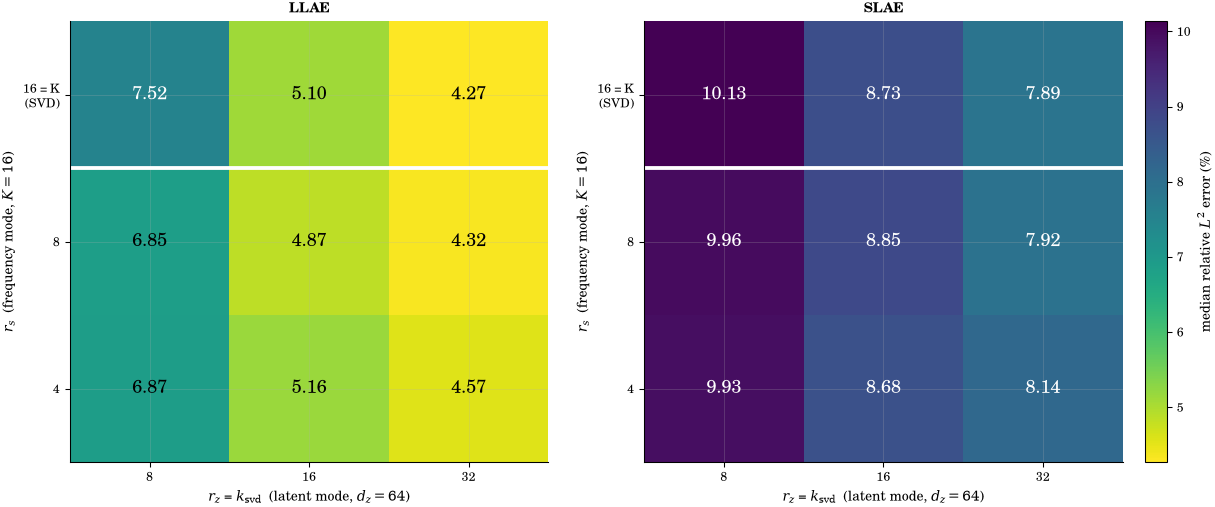

  ↳ article/images/compress_grid.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/compress_grid.pdf')

In [10]:
R_S  = list(R_S_GRID) + [K_FULL]     # the last level is the SVD row
R_Z  = sorted({d['r_z'] for d in meta.values()})
FAMS = ['LLAE', 'SLAE']
RS_LABELS = [str(r) for r in R_S_GRID] + [f'{K_FULL} = K\n(SVD)']


def _lookup(fam, r_s, r_z):
    """Checkpoint of one grid cell — r_s = K resolves to the SVD variant."""
    for n in PLOTTED:
        d = meta[n]
        if d['family'] == fam and d['r_s'] == r_s and d['r_z'] == r_z:
            return n
    return None


def grid_matrix(fam, key, stat=np.median):
    M = np.full((len(R_S), len(R_Z)), np.nan)
    for i, rs in enumerate(R_S):
        for j, rz in enumerate(R_Z):
            n = _lookup(fam, rs, rz)
            if n is not None:
                M[i, j] = stat(results[n][key])
    return M


fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))
vals = np.concatenate([grid_matrix(f, 'l2rel').ravel() for f in FAMS])
vmin, vmax = np.nanmin(vals), np.nanmax(vals)

for ax, fam in zip(axes, FAMS):
    M = grid_matrix(fam, 'l2rel')
    im = ax.imshow(M, cmap='viridis_r', vmin=vmin, vmax=vmax, origin='lower', aspect='auto')
    for i in range(len(R_S)):
        for j in range(len(R_Z)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f'{M[i, j]:.2f}', ha='center', va='center', fontsize=12,
                        color='white' if M[i, j] > (vmin + vmax) / 2 else 'black')
    # Separate the uncompressed-frequency row: it is a different model, not another rank.
    ax.axhline(len(R_S_GRID) - 0.5, color='white', lw=2.5)
    ax.set_xticks(range(len(R_Z))); ax.set_xticklabels(R_Z)
    ax.set_yticks(range(len(R_S))); ax.set_yticklabels(RS_LABELS)
    ax.set_xlabel(r'$r_z$ = $k_{\mathrm{svd}}$  (latent mode, $d_z = 64$)')
    ax.set_ylabel(r'$r_s$  (frequency mode, $K = 16$)')
    ax.set_title(fam, fontweight='bold')

fig.colorbar(im, ax=axes, label=r'median relative $L^2$ error (%)', fraction=0.03, pad=0.02)
fig.suptitle(r'Median field error over the latent-compression grid $(r_s, r_z)$ — test set '
             r'($n = 1620$); bottom row = SVD', fontweight='bold')
plt.show()
figstyle.save("grid")

## 7. Rank sweeps: $r_s$ and $r_z$ separately

Pooled over the other rank. The $r_s = K$ violin is the SVD group, in the lighter shade of the
family colour.

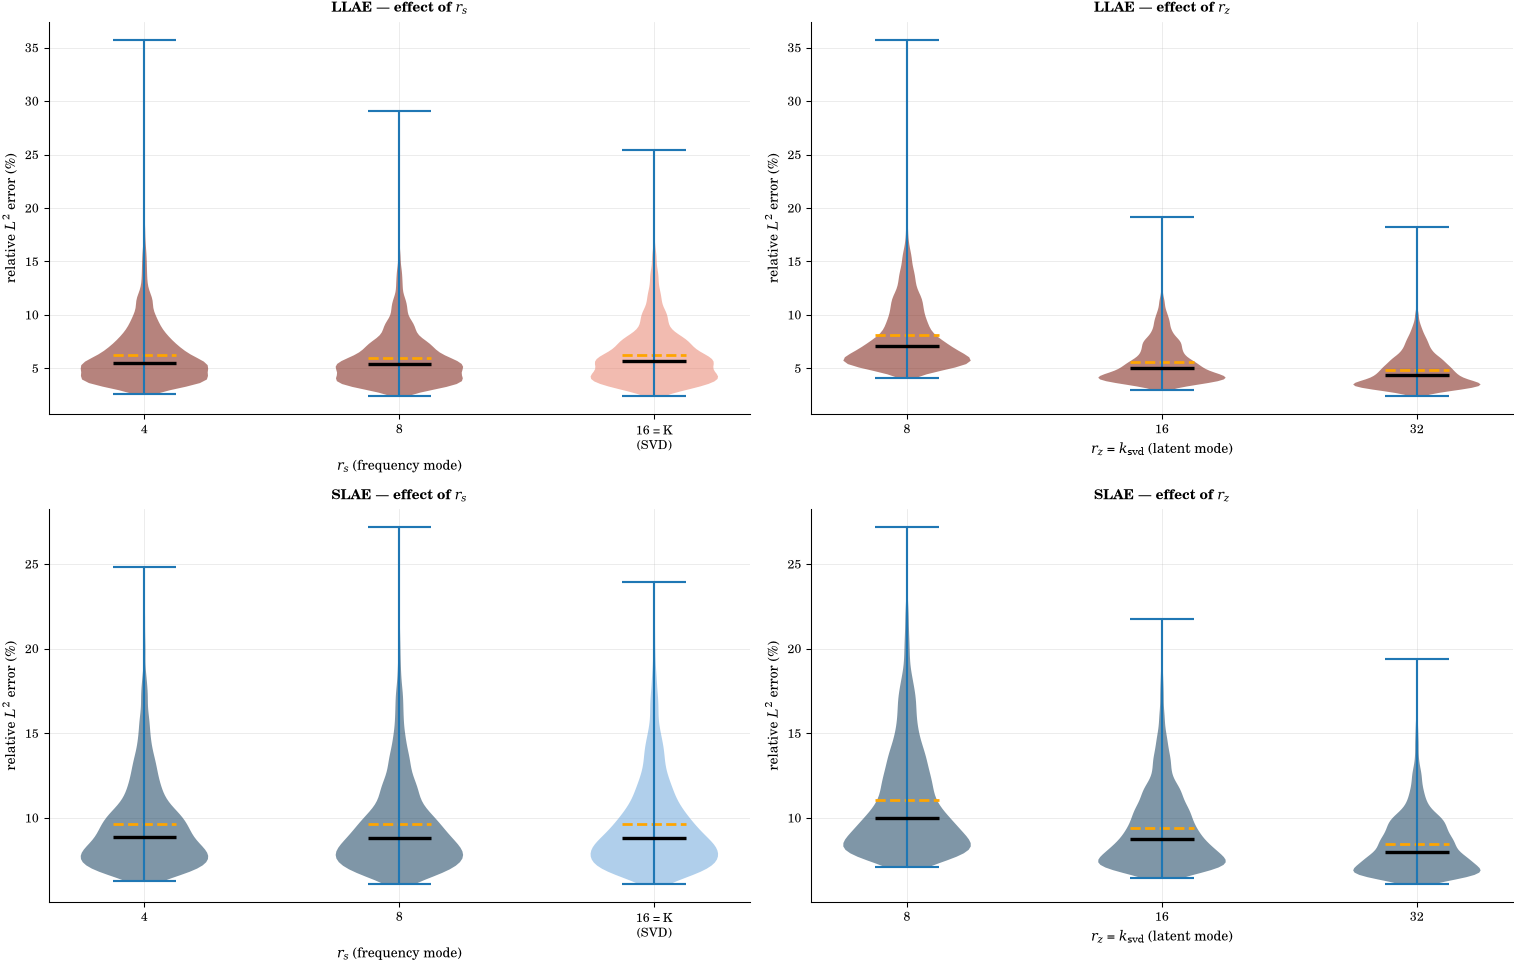

  ↳ article/images/compress_rank_sweep.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/compress_rank_sweep.pdf')

In [11]:
def _violin(ax, groups, labels, colors, title, xlabel):
    keys = list(groups)
    data = [groups[k] for k in keys]
    if not data:
        ax.set_title(f'{title}\n(no data)'); ax.axis('off'); return
    parts = ax.violinplot(data, showmedians=True, showmeans=True, showextrema=True)
    for b, c in zip(parts['bodies'], colors):
        b.set_facecolor(c); b.set_alpha(0.55)
    parts['cmedians'].set_color('black'); parts['cmedians'].set_linewidth(2.2)
    parts['cmeans'].set_color('orange');  parts['cmeans'].set_linestyle('--'); parts['cmeans'].set_linewidth(1.8)
    ax.set_xticks(range(1, len(keys) + 1)); ax.set_xticklabels(labels)
    ax.set_xlabel(xlabel); ax.set_ylabel(r'relative $L^2$ error (%)')
    ax.set_title(title, fontweight='bold'); ax.grid(axis='y', alpha=0.3)


def _cell_color(fam, r_s):
    n = next((m for m in PLOTTED if meta[m]['family'] == fam and meta[m]['r_s'] == r_s), None)
    return PALETTE[meta[n]['cls']] if n else '0.5'


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for row, fam in enumerate(FAMS):
    g_rs, c_rs = {}, []
    for rs in R_S:
        pool = [results[_lookup(fam, rs, rz)]['l2rel'] for rz in R_Z if _lookup(fam, rs, rz)]
        if pool:
            g_rs[rs] = np.concatenate(pool); c_rs.append(_cell_color(fam, rs))
    g_rz, c_rz = {}, []
    for rz in R_Z:
        pool = [results[_lookup(fam, rs, rz)]['l2rel'] for rs in R_S if _lookup(fam, rs, rz)]
        if pool:
            g_rz[rz] = np.concatenate(pool); c_rz.append(_cell_color(fam, R_S_GRID[-1]))

    _violin(axes[row, 0], g_rs, RS_LABELS, c_rs,
            f'{fam} — effect of $r_s$', r'$r_s$ (frequency mode)')
    _violin(axes[row, 1], g_rz, list(g_rz), c_rz,
            f'{fam} — effect of $r_z$', r'$r_z$ = $k_{\mathrm{svd}}$ (latent mode)')

fig.suptitle('Latent-compression rank sweeps (pooled over the other rank)', fontweight='bold')
plt.tight_layout()
plt.show()
figstyle.save("rank_sweep")

## 8. Error decomposition: truncation vs regression

$\varepsilon_{\mathrm{trunc}}$ is a *latent* energy, not a field error: discarding 80 % of the
latent norm costs only ~7 % on $U(t)$, since the removed directions carry little decodable
information. Its variation with $(r_s, r_z)$ is what matters, hence the log scale.

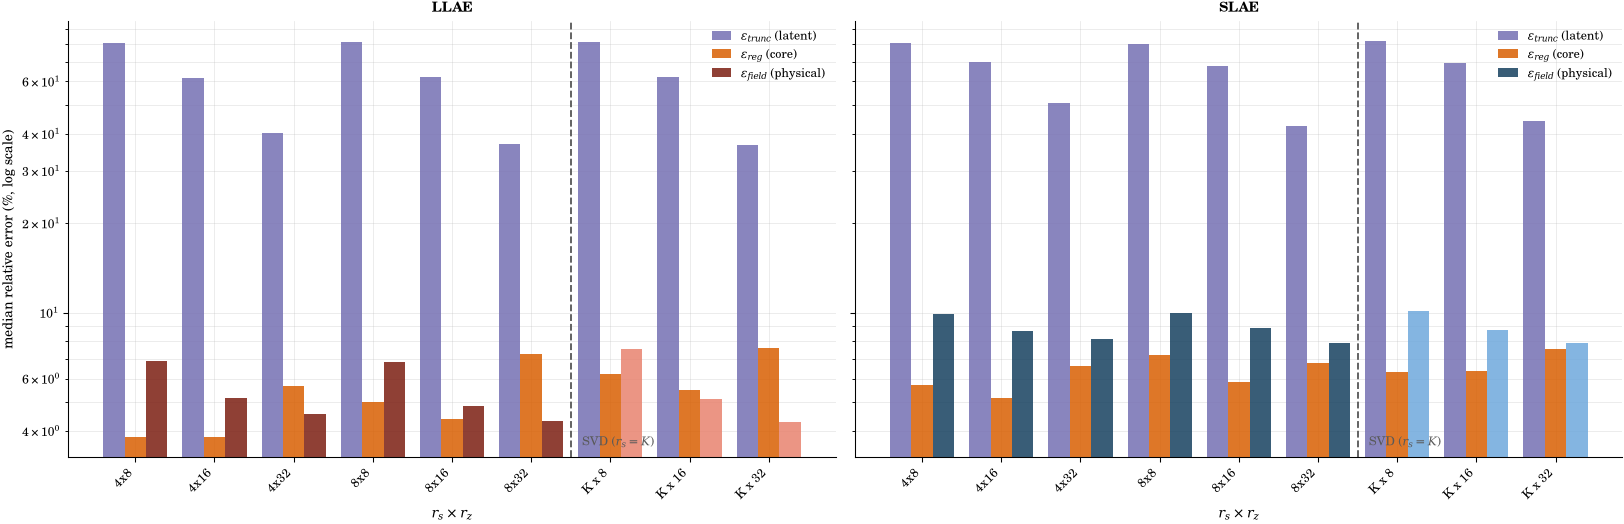

  ↳ article/images/compress_error_decomp.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/compress_error_decomp.pdf')

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for ax, fam in zip(axes, FAMS):
    labels, tr, rg, fld, col = [], [], [], [], []
    for rs in R_S:
        for rz in R_Z:
            n = _lookup(fam, rs, rz)
            if n is None:
                continue
            labels.append(f'K x {rz}' if rs == K_FULL else f'{rs}x{rz}')
            tr.append(np.median(results[n]['trunc']))
            rg.append(np.median(results[n]['reg']))
            fld.append(np.median(results[n]['l2rel']))
            col.append(PALETTE[meta[n]['cls']])
    x = np.arange(len(labels)); w = 0.27
    ax.bar(x - w, tr,  w, label=r'$\varepsilon_{trunc}$ (latent)',  color='#7570b3', alpha=0.85, zorder=2)
    ax.bar(x,     rg,  w, label=r'$\varepsilon_{reg}$ (core)',      color='#d95f02', alpha=0.85, zorder=2)
    ax.bar(x + w, fld, w, label=r'$\varepsilon_{field}$ (physical)', color=col, alpha=0.85, zorder=2)
    # Boundary between the Tucker block and the uncompressed-frequency (SVD) block.
    n_tuck = len(R_S_GRID) * len(R_Z)
    ax.axvline(n_tuck - 0.5, color='0.35', ls='--', lw=1.2, zorder=1)
    ax.text(n_tuck - 0.4, 0.02, ' SVD ($r_s = K$)', ha='left', va='bottom', fontsize=8,
            color='0.35', transform=ax.get_xaxis_transform())
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha='right')
    ax.set_xlabel(r'$r_s \times r_z$'); ax.set_title(fam, fontweight='bold')
    ax.set_yscale('log')
    ax.grid(axis='y', alpha=0.3, which='both', zorder=0); ax.legend(fontsize=8)

axes[0].set_ylabel('median relative error (%, log scale)')
fig.suptitle('Error decomposition: latent truncation vs surrogate regression', fontweight='bold')
plt.tight_layout()
plt.show()
figstyle.save("error_decomp")

## 9. Error vs compression and vs surrogate size

The compression ratio $\rho = r_s r_z / (K d_z)$ is the size of the surrogate target relative to
the direct pipeline ($K d_z = 1024$ scalars). SVD spans $\rho \in \{0.125, 0.25, 0.5\}$, Tucker
reaches down to $0.031$ — the two together sweep a $16\times$ range on the same axis.

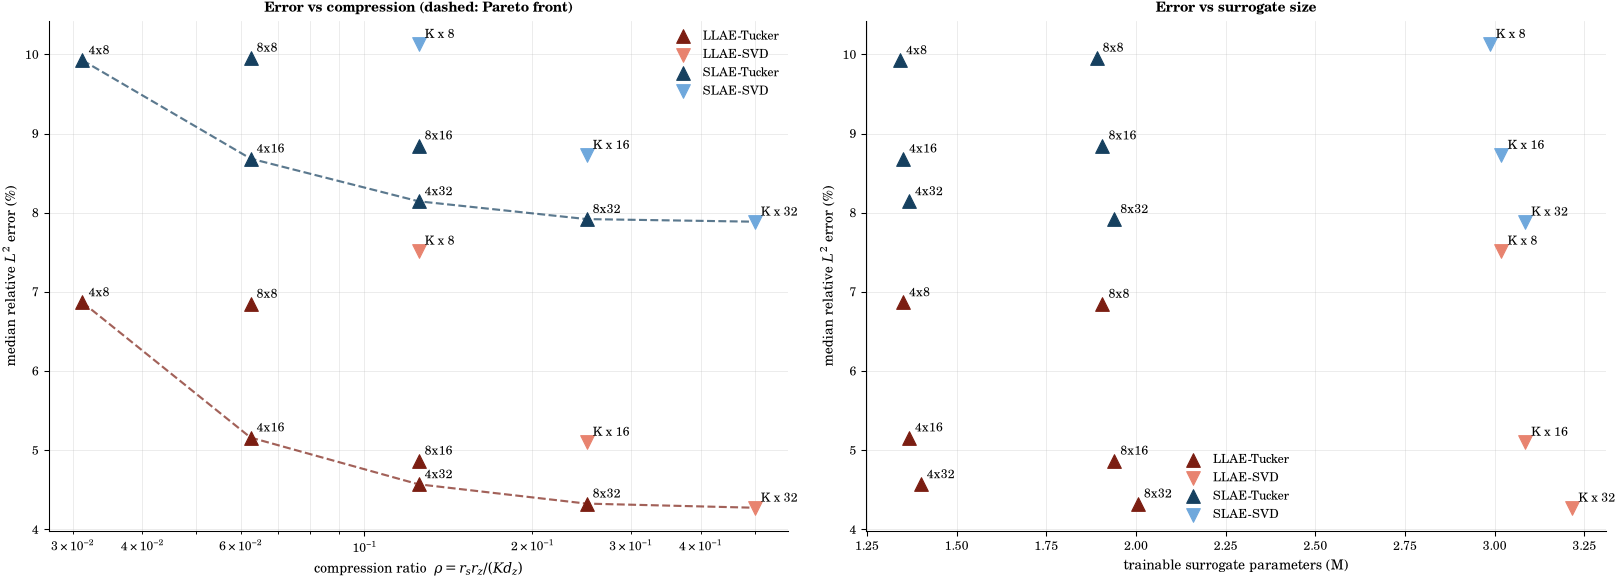

  ↳ article/images/compress_pareto.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/compress_pareto.pdf')

In [13]:
MARK = {'Tucker': figstyle.MARKERS['tucker'], 'SVD': figstyle.MARKERS['svd']}


def _pareto(xs, ys):
    """Pareto front (increasing compression ratio, decreasing error)."""
    fx, fy, best = [], [], np.inf
    for i in np.argsort(xs):
        if ys[i] < best:
            best = ys[i]; fx.append(xs[i]); fy.append(ys[i])
    return fx, fy


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))

for fam in FAMS:
    names = [n for n in PLOTTED if meta[n]['family'] == fam]
    xs  = np.array([meta[n]['ratio'] for n in names])
    ys  = np.array([np.median(results[n]['l2rel']) for n in names])
    ps  = np.array([meta[n]['n_surr'] / 1e6 for n in names])
    lbl = [(f"K x {meta[n]['r_z']}" if meta[n]['method'] == 'SVD'
            else f"{meta[n]['r_s']}x{meta[n]['r_z']}") for n in names]

    for ax, x_ in ((ax1, xs), (ax2, ps)):
        for meth in ('Tucker', 'SVD'):
            sel = [i for i, n in enumerate(names) if meta[n]['method'] == meth]
            if not sel:
                continue
            ax.scatter(x_[sel], ys[sel], color=PALETTE[meta[names[sel[0]]]['cls']],
                       marker=MARK[meth], s=80, label=f'{fam}-{meth}', zorder=3)
        for x, y, t in zip(x_, ys, lbl):
            ax.annotate(t, (x, y), fontsize=8, xytext=(4, 4), textcoords='offset points')

    # several (r_s, r_z) share the same ratio -> scatter + Pareto front, not a line plot
    fx, fy = _pareto(xs, ys)
    ax1.plot(fx, fy, '--', color=PALETTE[meta[names[0]]['cls']], alpha=0.7, lw=1.4, zorder=2)

ax1.set_xscale('log')
ax1.set_xlabel(r'compression ratio  $\rho = r_s r_z / (K d_z)$')
ax1.set_ylabel(r'median relative $L^2$ error (%)')
ax1.set_title('Error vs compression (dashed: Pareto front)', fontweight='bold')
ax1.grid(alpha=0.3, which='both'); ax1.legend(fontsize=8)

ax2.set_xlabel('trainable surrogate parameters (M)')
ax2.set_ylabel(r'median relative $L^2$ error (%)')
ax2.set_title('Error vs surrogate size', fontweight='bold')
ax2.grid(alpha=0.3); ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()
figstyle.save("pareto")

## 10. Per-checkpoint error distributions

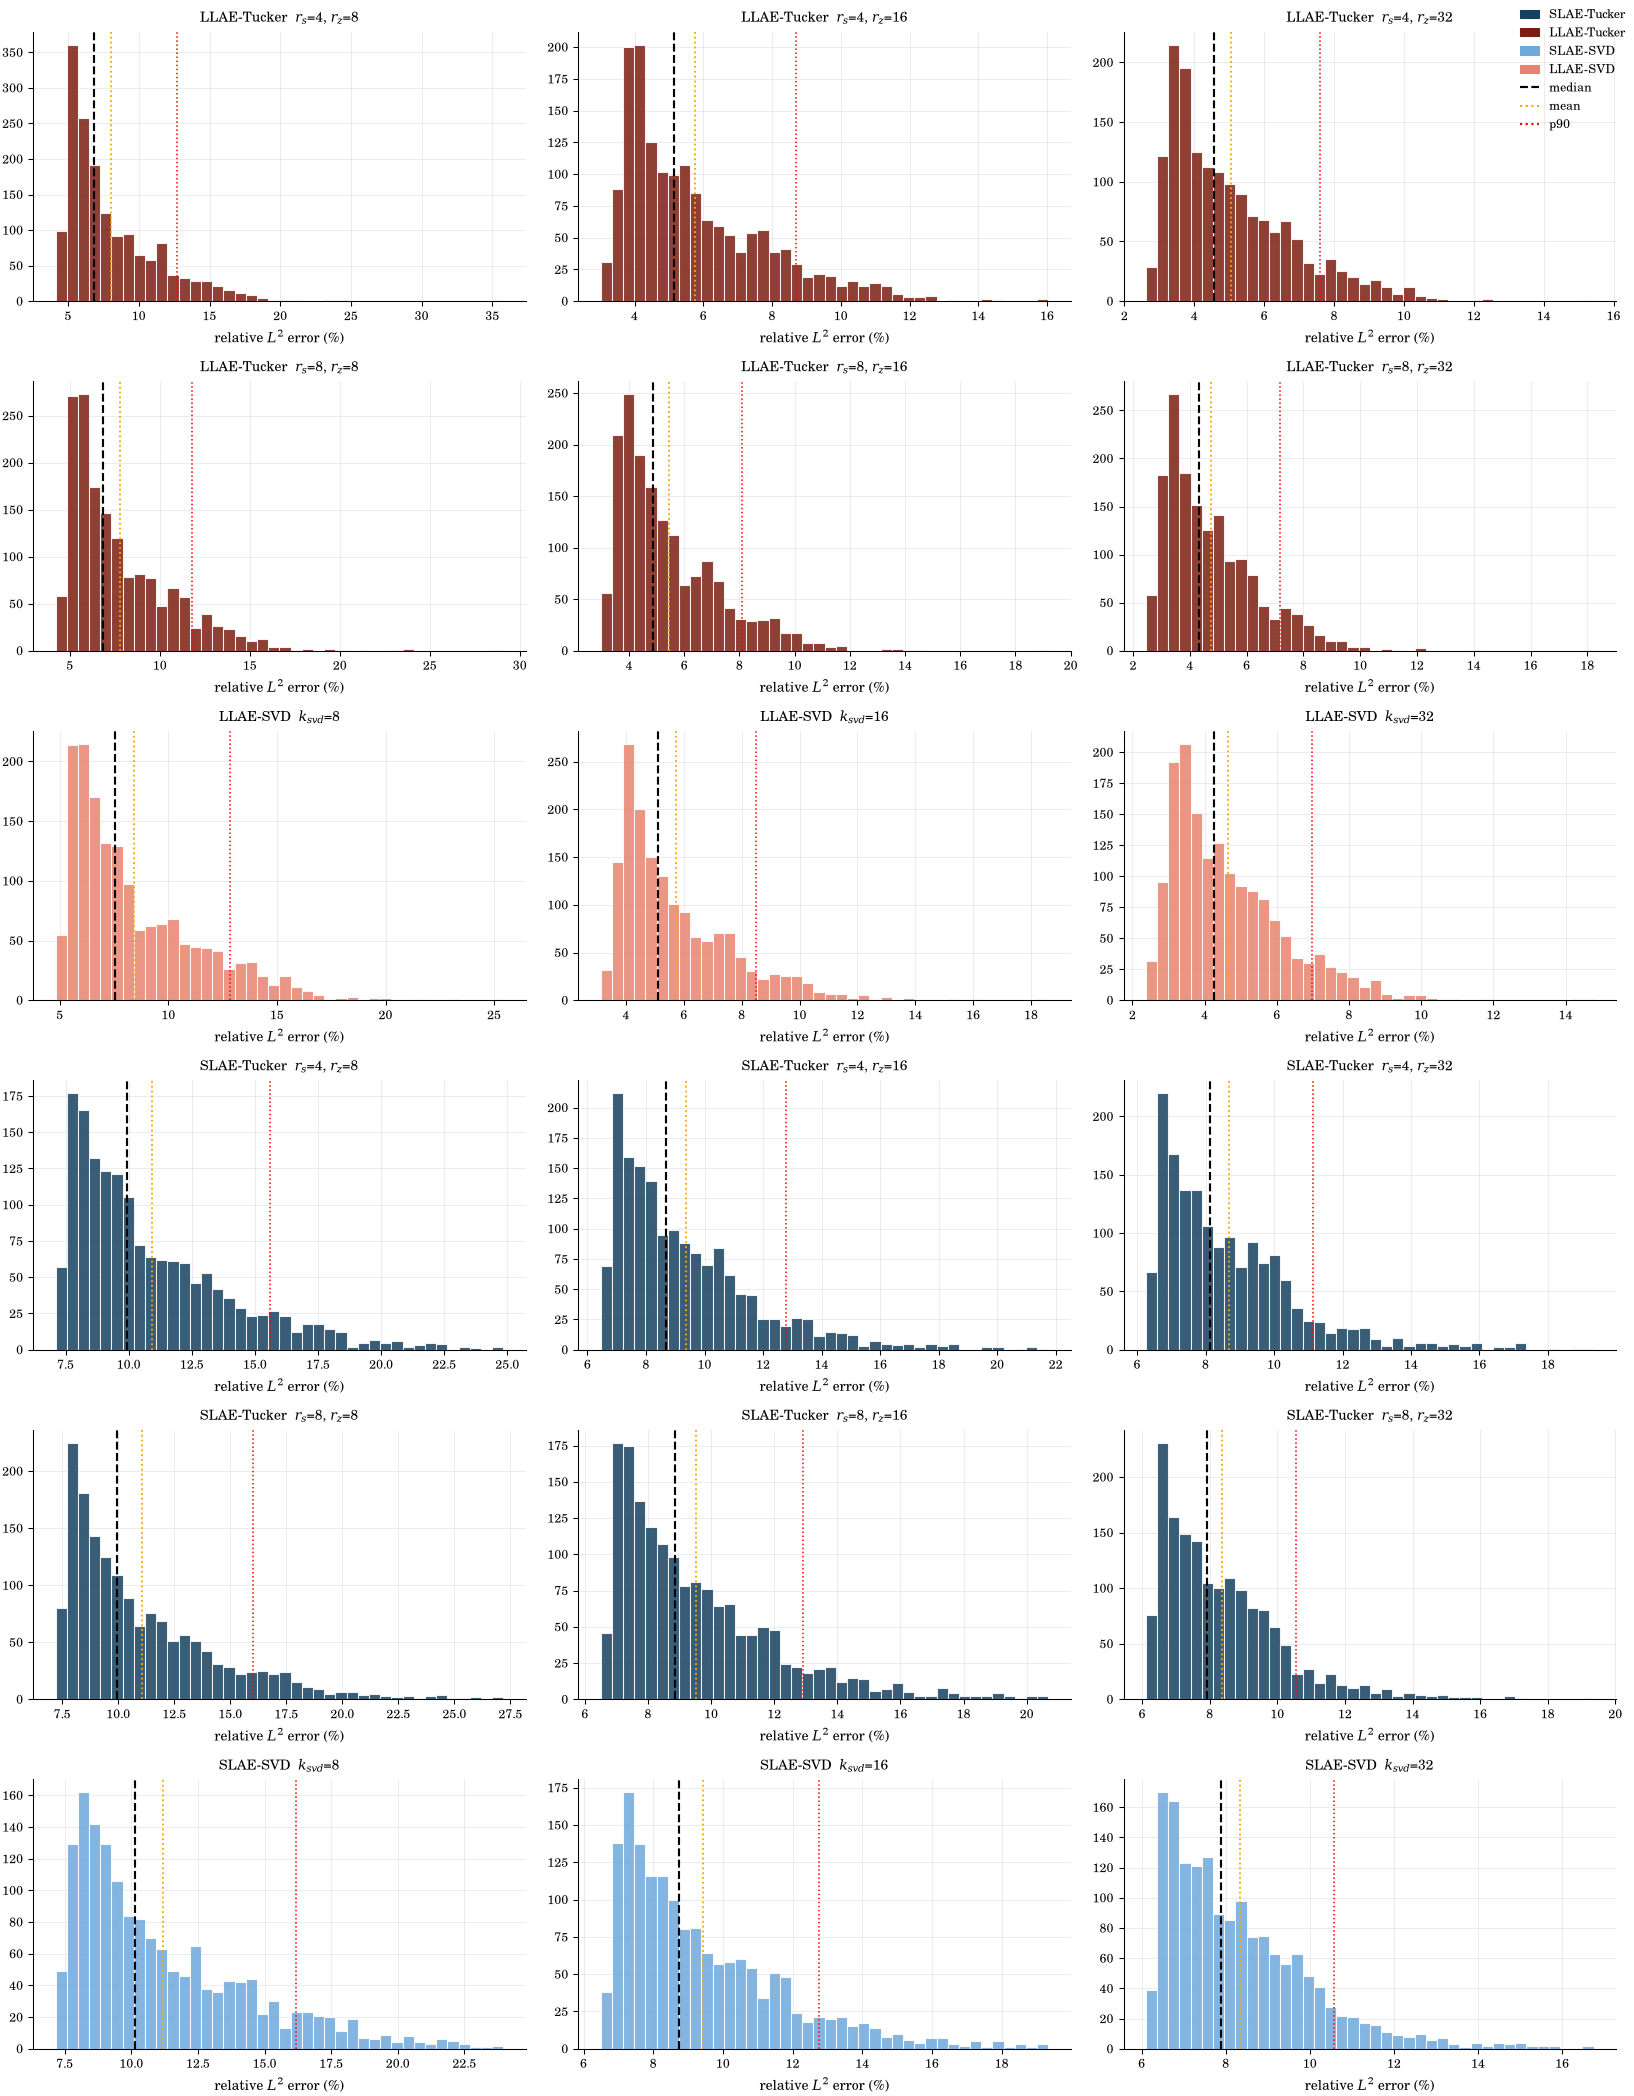

  ↳ article/images/compress_hist.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/compress_hist.pdf')

In [14]:
ncols = 3
nrows = int(np.ceil(len(PLOTTED) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, n in zip(axes, PLOTTED):
    d, l2 = meta[n], results[n]['l2rel']
    ax.hist(l2, bins=40, color=PALETTE[d['cls']], edgecolor='white', alpha=0.85)
    ax.axvline(np.median(l2),         color='black',  linestyle='--', linewidth=1.4)
    ax.axvline(np.mean(l2),           color='orange', linestyle=':',  linewidth=1.2)
    ax.axvline(np.percentile(l2, 90), color='red',    linestyle=':',  linewidth=1.0)
    rank = (f"$k_{{svd}}$={d['r_z']}" if d['method'] == 'SVD'
            else f"$r_s$={d['r_s']}, $r_z$={d['r_z']}")
    ax.set_title(f"{FAMILY[d['cls']]}  {rank}", fontsize=9)
    ax.set_xlabel(r'relative $L^2$ error (%)')
for ax in axes[len(PLOTTED):]:
    ax.axis('off')

handles = [Patch(color=PALETTE[c], label=FAMILY[c]) for c in FAMILY]
handles += [plt.Line2D([], [], color='black', ls='--', label='median'),
            plt.Line2D([], [], color='orange', ls=':', label='mean'),
            plt.Line2D([], [], color='red', ls=':', label='p90')]
fig.legend(handles=handles, loc='upper right', fontsize=8)
fig.suptitle(r'Relative $L^2$ error on the physical field $U(t)$ — test set', fontweight='bold')
plt.tight_layout()
plt.show()
figstyle.save("hist")

## 11. Inference latency


benchmark:   0%|          | 0/18 [00:00<?, ?it/s]


benchmark:   6%|▌         | 1/18 [00:05<01:31,  5.39s/it]

LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz8 lat=   25.8±  4.4 ms  flops=  48.2 G  mem=   589 MB  E=2400.6 mJ



benchmark:  11%|█         | 2/18 [00:08<01:07,  4.25s/it]

LLAETuckerModel__llae_ld64_K16_g0.01__t4h2_rs4rz16 lat=   26.2±  4.6 ms  flops=  48.2 G  mem=   590 MB  E=3277.4 mJ


...


benchmark:  94%|█████████▍| 17/18 [00:54<00:02,  2.71s/it]

SLAESVDModel__slae_ld64_K16_g0.01__t4h2_ksvd16 lat=   16.1±  0.3 ms  flops=  30.3 G  mem=   240 MB  E=1758.0 mJ



benchmark: 100%|██████████| 18/18 [00:56<00:00,  2.69s/it]


benchmark: 100%|██████████| 18/18 [00:56<00:00,  3.15s/it]

SLAESVDModel__slae_ld64_K16_g0.01__t4h2_ksvd32 lat=   16.2±  0.4 ms  flops=  30.3 G  mem=   241 MB  E=1764.7 mJ
checkpoint                                       lat (ms)       ±   FLOPs (G)   mem (MB)    E (mJ)
--------------------------------------------------------------------------------------------------
SLAE-Tucker  $r_s$=4, $r_z$=8                        15.2     0.4        30.3        214    1730.6
SLAE-Tucker  $r_s$=4, $r_z$=16                       15.2     0.4        30.3        214    1741.4
SLAE-Tucker  $r_s$=4, $r_z$=32                       15.4     0.6        30.3        215    1754.0
SLAE-Tucker  $r_s$=8, $r_z$=8                        15.5     0.4        30.3        223    1764.3
SLAE-Tucker  $r_s$=8, $r_z$=32                       15.7     0.5        30.3        223    1753.2
SLAE-Tucker  $r_s$=8, $r_z$=16                       15.9     0.6        30.3        223    1744.3
SLAE-SVD  $k_{svd}$=16                               16.1     0.3        30.3        240    1758

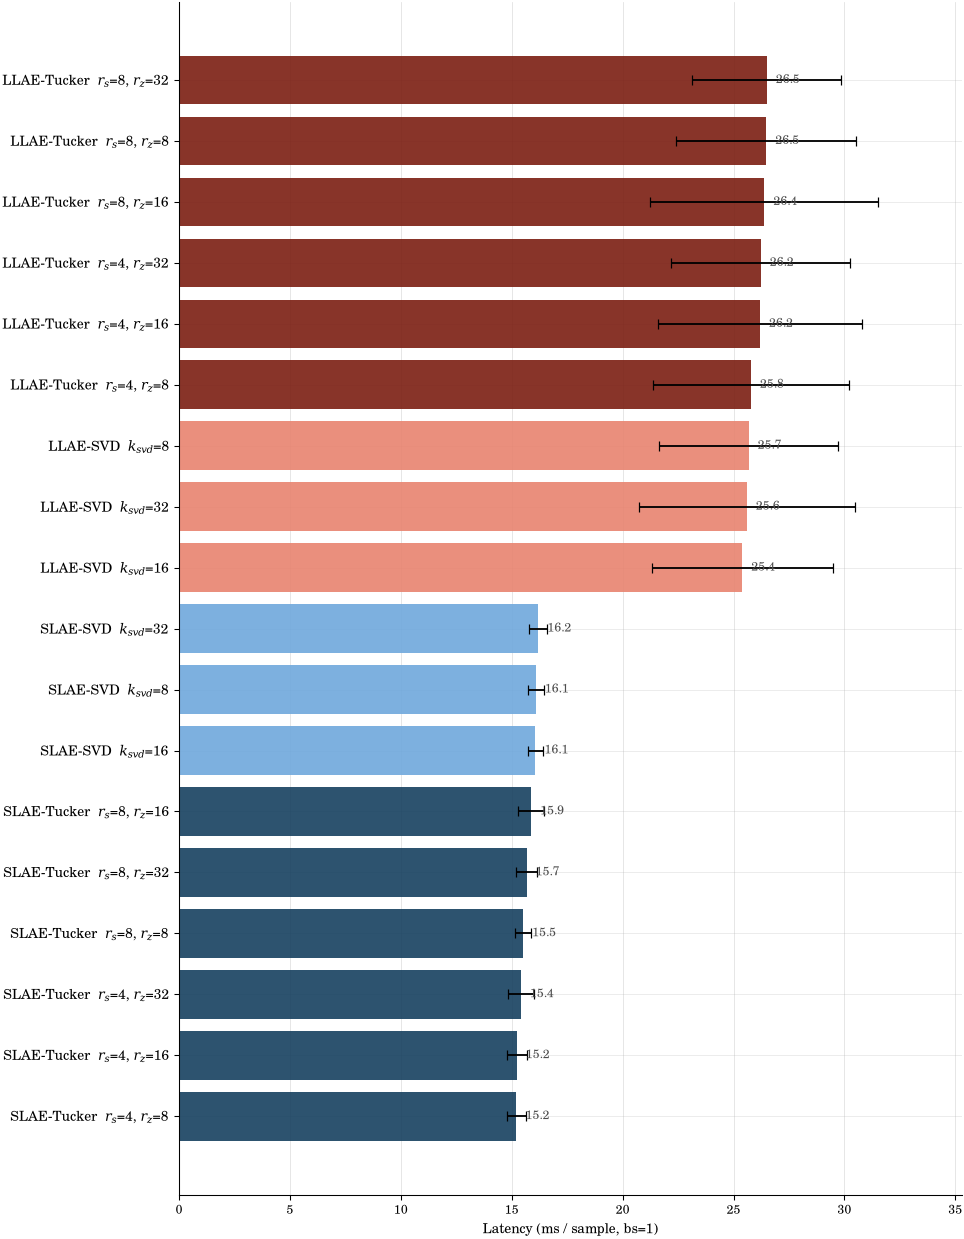

  ↳ article/images/compress_bench_latency.pdf


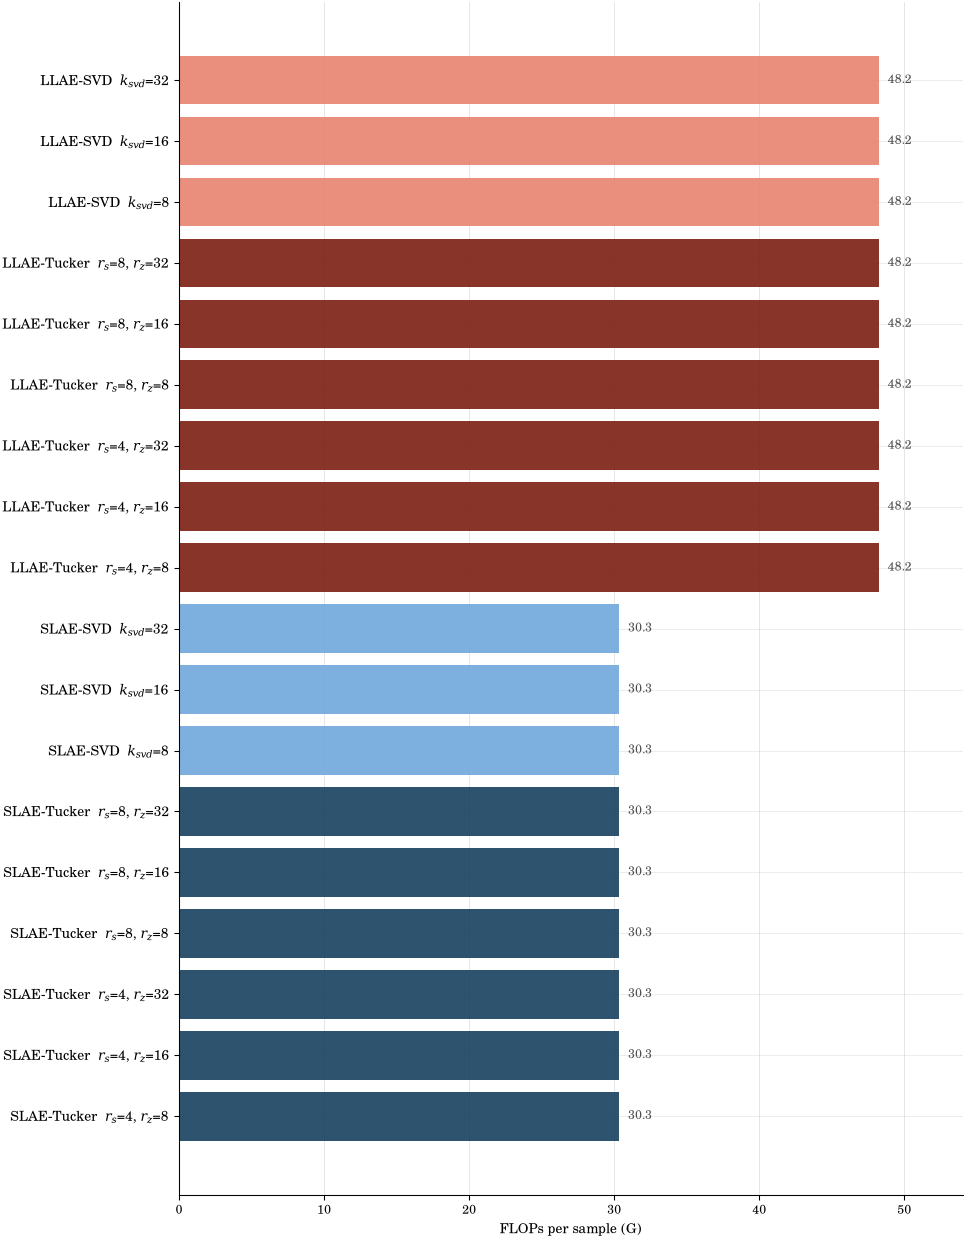

  ↳ article/images/compress_bench_flops.pdf


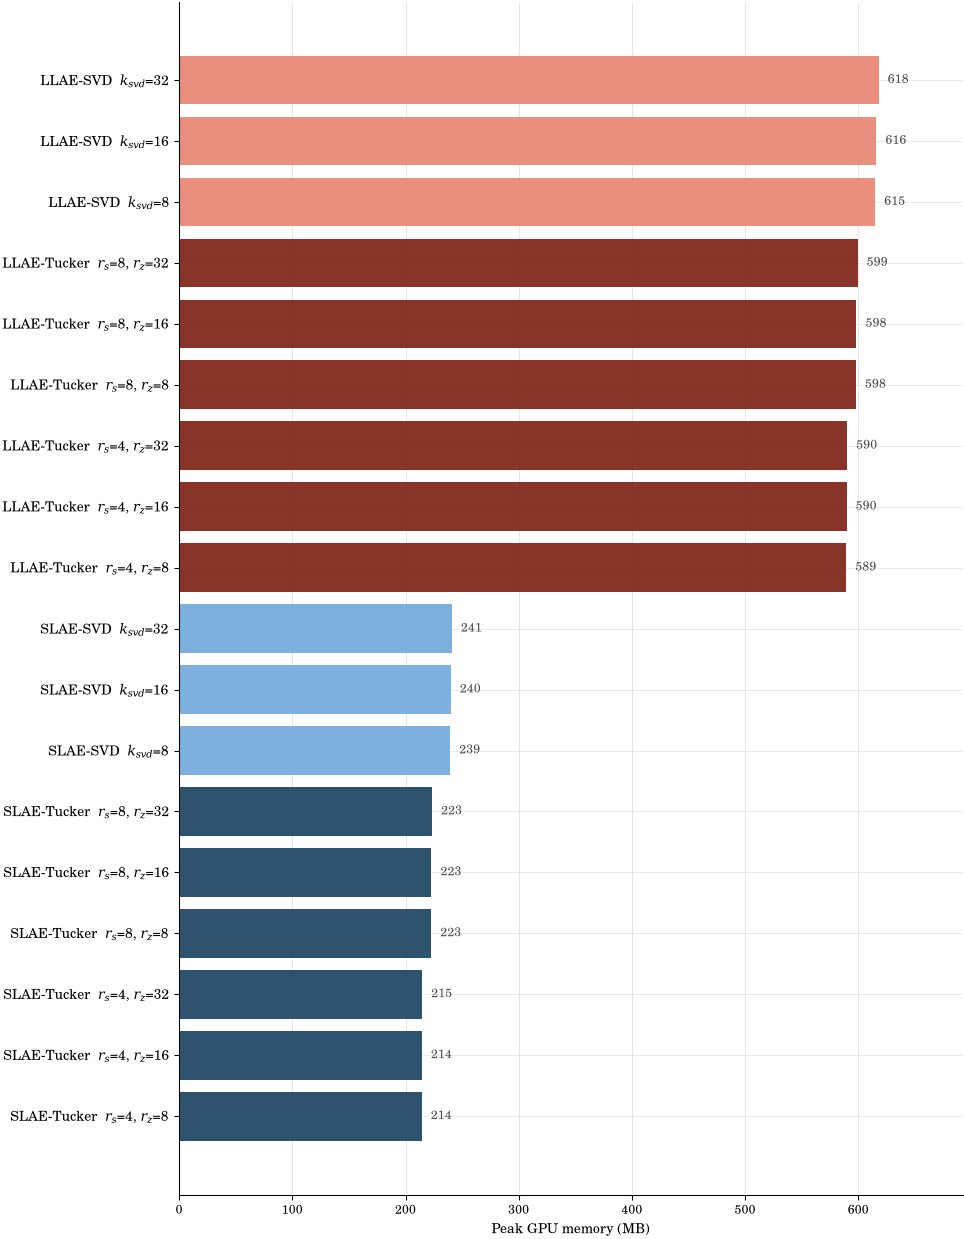

  ↳ article/images/compress_bench_memory.pdf


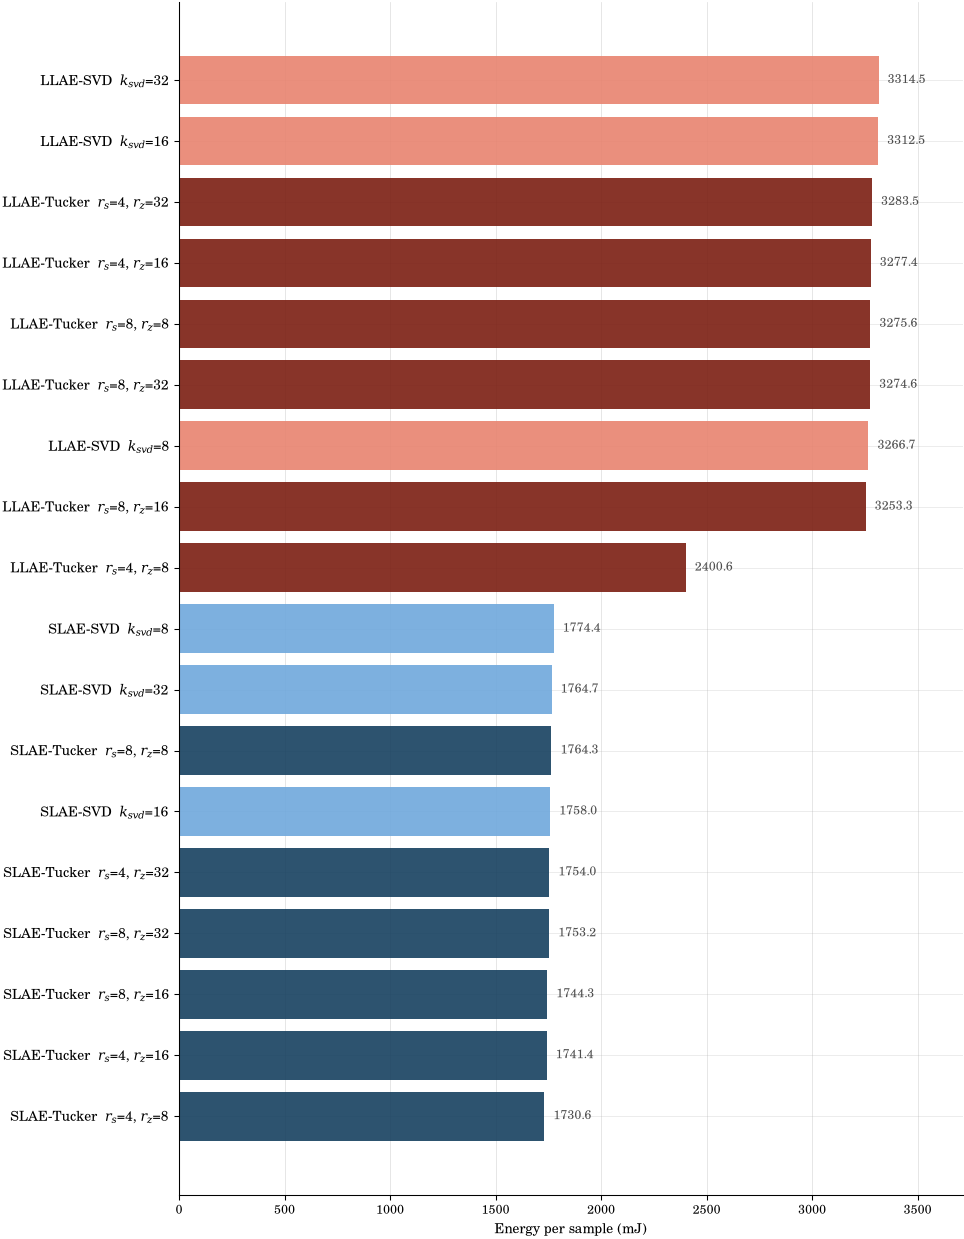

  ↳ article/images/compress_bench_energy.pdf


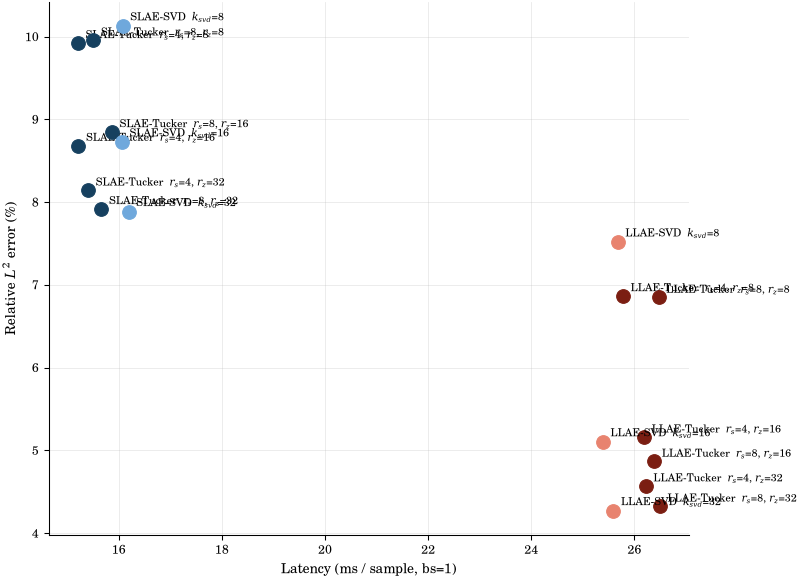

  ↳ article/images/compress_cost_latency.pdf


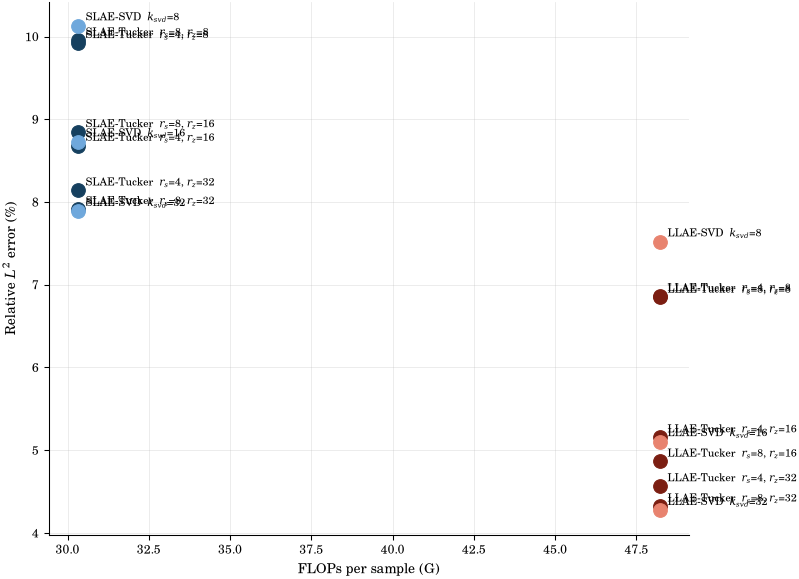

  ↳ article/images/compress_cost_flops.pdf


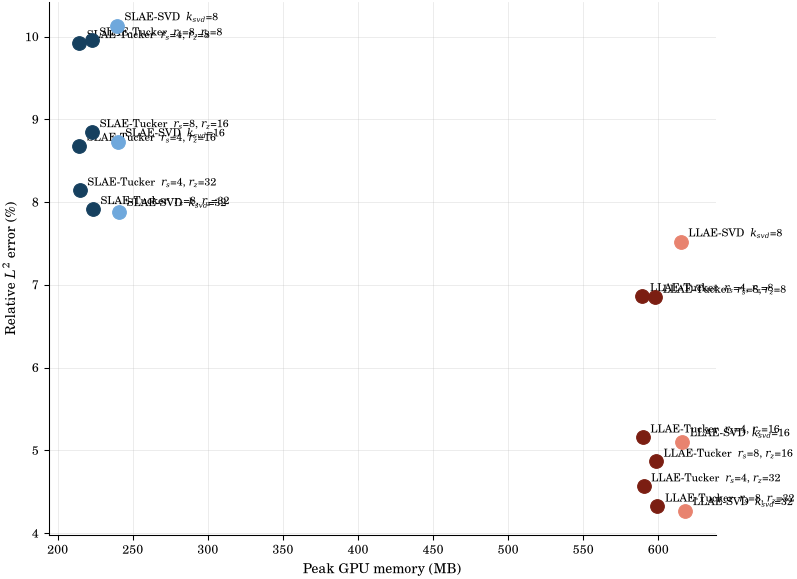

  ↳ article/images/compress_cost_memory.pdf


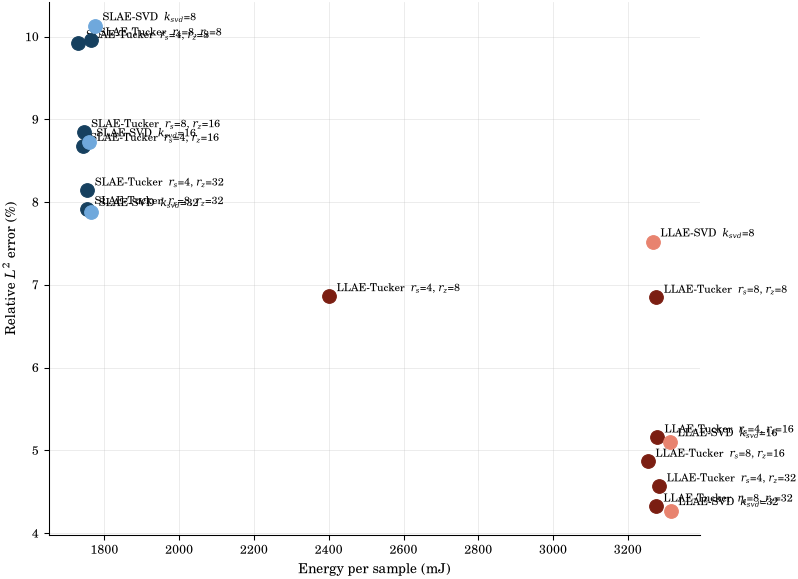

  ↳ article/images/compress_cost_energy.pdf


['cost_latency', 'cost_flops', 'cost_memory', 'cost_energy']

In [15]:
import benchmark   # methodologie commune a tous les notebooks

bench = {}
for n in tqdm(PLOTTED, desc='benchmark'):
    pipe = InferencePipeline.from_checkpoint(meta[n]['path'], device=device)
    tm = pipe.ckpt['theta_mean'].to(device).float(); ts = pipe.ckpt['theta_std'].to(device).float()
    tn = (torch.from_numpy(theta_np[test_idx[:1]]).to(device) - tm) / ts

    def run():
        with torch.no_grad():
            pipe.model.generate(tn)

    bench[n] = benchmark.measure(run, device, name=n)
    pipe.model.cpu(); del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()


def _label(n):
    d = meta[n]
    rank = (f"$k_{{svd}}$={d['r_z']}" if d['method'] == 'SVD'
            else f"$r_s$={d['r_s']}, $r_z$={d['r_z']}")
    return f"{FAMILY[d['cls']]}  {rank}"


def _bench_color(n):
    return PALETTE[meta[n]['cls']]


# One figure per metric, plus the matching accuracy/cost scatter.
benchmark.table(bench, label_of=_label)

benchmark.figures(bench, label_of=_label, color_of=_bench_color, device=device)

_acc = {n: float(np.median(results[n]['l2rel'])) for n in PLOTTED if n in bench}
benchmark.scatter(bench, _acc, label_of=_label, color_of=_bench_color,
                  device=device, ylabel=figstyle.LABELS['l2rel'])

## 12. Summary table

In [16]:
hdr = (f"{'variant':<12} {'r_s':>5} {'r_z':>4} {'ratio':>7} {'params':>10} "
       f"{'median':>8} {'mean':>7} {'p90':>7} {'trunc':>7} {'reg':>7} {'lat_ms':>7}")
print(hdr); print('-' * len(hdr))
for n in PLOTTED:
    d, r = meta[n], results[n]
    rs = f"{d['r_s']}=K" if d['method'] == 'SVD' else str(d['r_s'])
    print(f"{FAMILY[d['cls']]:<12} {rs:>5} {d['r_z']:>4} {d['ratio']:>7.3f} {d['n_surr']:>10,} "
          f"{np.median(r['l2rel']):>8.2f} {np.mean(r['l2rel']):>7.2f} "
          f"{np.percentile(r['l2rel'], 90):>7.2f} {np.median(r['trunc']):>7.2f} "
          f"{np.median(r['reg']):>7.2f} {bench[n]['lat_med']:>7.2f}")

best = min(PLOTTED, key=lambda n: np.median(results[n]['l2rel']))
b    = meta[best]
print(f'\nn = {len(test_idx)} test simulations, errors in %. '
      f"Best: {_tag(b)} ({np.median(results[best]['l2rel']):.2f}% median, ratio {b['ratio']:.3f}).")

# Equal-target-size comparison: which factorisation spends its budget best.
print('\nAt equal surrogate target size (r_s r_z scalars):')
by_size = {}
for n in PLOTTED:
    by_size.setdefault((meta[n]['family'], meta[n]['r_s'] * meta[n]['r_z']), []).append(n)
for (fam, size), names in sorted(by_size.items()):
    if len(names) < 2:
        continue
    entries = '   '.join(
        f"{meta[n]['method']} "
        f"({'K' if meta[n]['method'] == 'SVD' else meta[n]['r_s']}x{meta[n]['r_z']}) "
        f"{np.median(results[n]['l2rel']):.2f}%"
        for n in sorted(names, key=lambda n: np.median(results[n]['l2rel'])))
    print(f'  {fam}  {size:>4} coefficients:  {entries}')

figstyle.summary()

variant        r_s  r_z   ratio     params   median    mean     p90   trunc     reg  lat_ms
-------------------------------------------------------------------------------------------
LLAE-Tucker      4    8   0.031  1,350,212     6.87    8.02   12.72   81.03    3.80   25.78
LLAE-Tucker      4   16   0.062  1,366,660     5.16    5.76    8.70   61.59    3.82   26.19
LLAE-Tucker      4   32   0.125  1,399,556     4.57    5.04    7.61   40.34    5.67   26.22
LLAE-Tucker      8    8   0.062  1,906,312     6.85    7.77   11.76   81.20    4.99   26.47
LLAE-Tucker      8   16   0.125  1,939,208     4.87    5.43    8.10   61.86    4.38   26.38
LLAE-Tucker      8   32   0.250  2,005,000     4.32    4.74    7.16   36.98    7.24   26.49
LLAE-SVD      16=K    8   0.125  3,018,512     7.52    8.43   12.85   81.20    6.24   25.67
LLAE-SVD      16=K   16   0.250  3,084,304     5.10    5.72    8.49   61.85    5.48   25.39
LLAE-SVD      16=K   32   0.500  3,215,888     4.27    4.65    6.98   36.73    7